##Regression Project: House Price Prediction

This notebook outlines a basic regression project to predict house prices. We'll cover the following steps:

1.  **Project Setup**: Import libraries and load the dataset.
2.  **Data Exploration (EDA)**: Understand the data characteristics.
3.  **Data Preprocessing**: Prepare the data for modeling.
4.  **Model Training**: Build and train a regression model.
5.  **Model Evaluation**: Assess the model's performance.

### 1. Project Setup: Import Libraries and Load Data

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Set display options for pandas DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# The target variable (MedHouseVal) is in housing.target
df['MedHouseVal'] = housing.target

print("California Housing dataset loaded.")
display(df.head())

California Housing dataset loaded.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 2. Data Exploration (EDA)

In [3]:
# To get basic information about the dataset
print("Dataset Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Descriptive Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
# Check for missing values
print("\nMissing Values:")
display(df.isnull().sum())


Missing Values:


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


### Visualize Data Distributions

 Plot histograms for all numerical columns to observe their distributions, identify outliers, and understand their ranges.

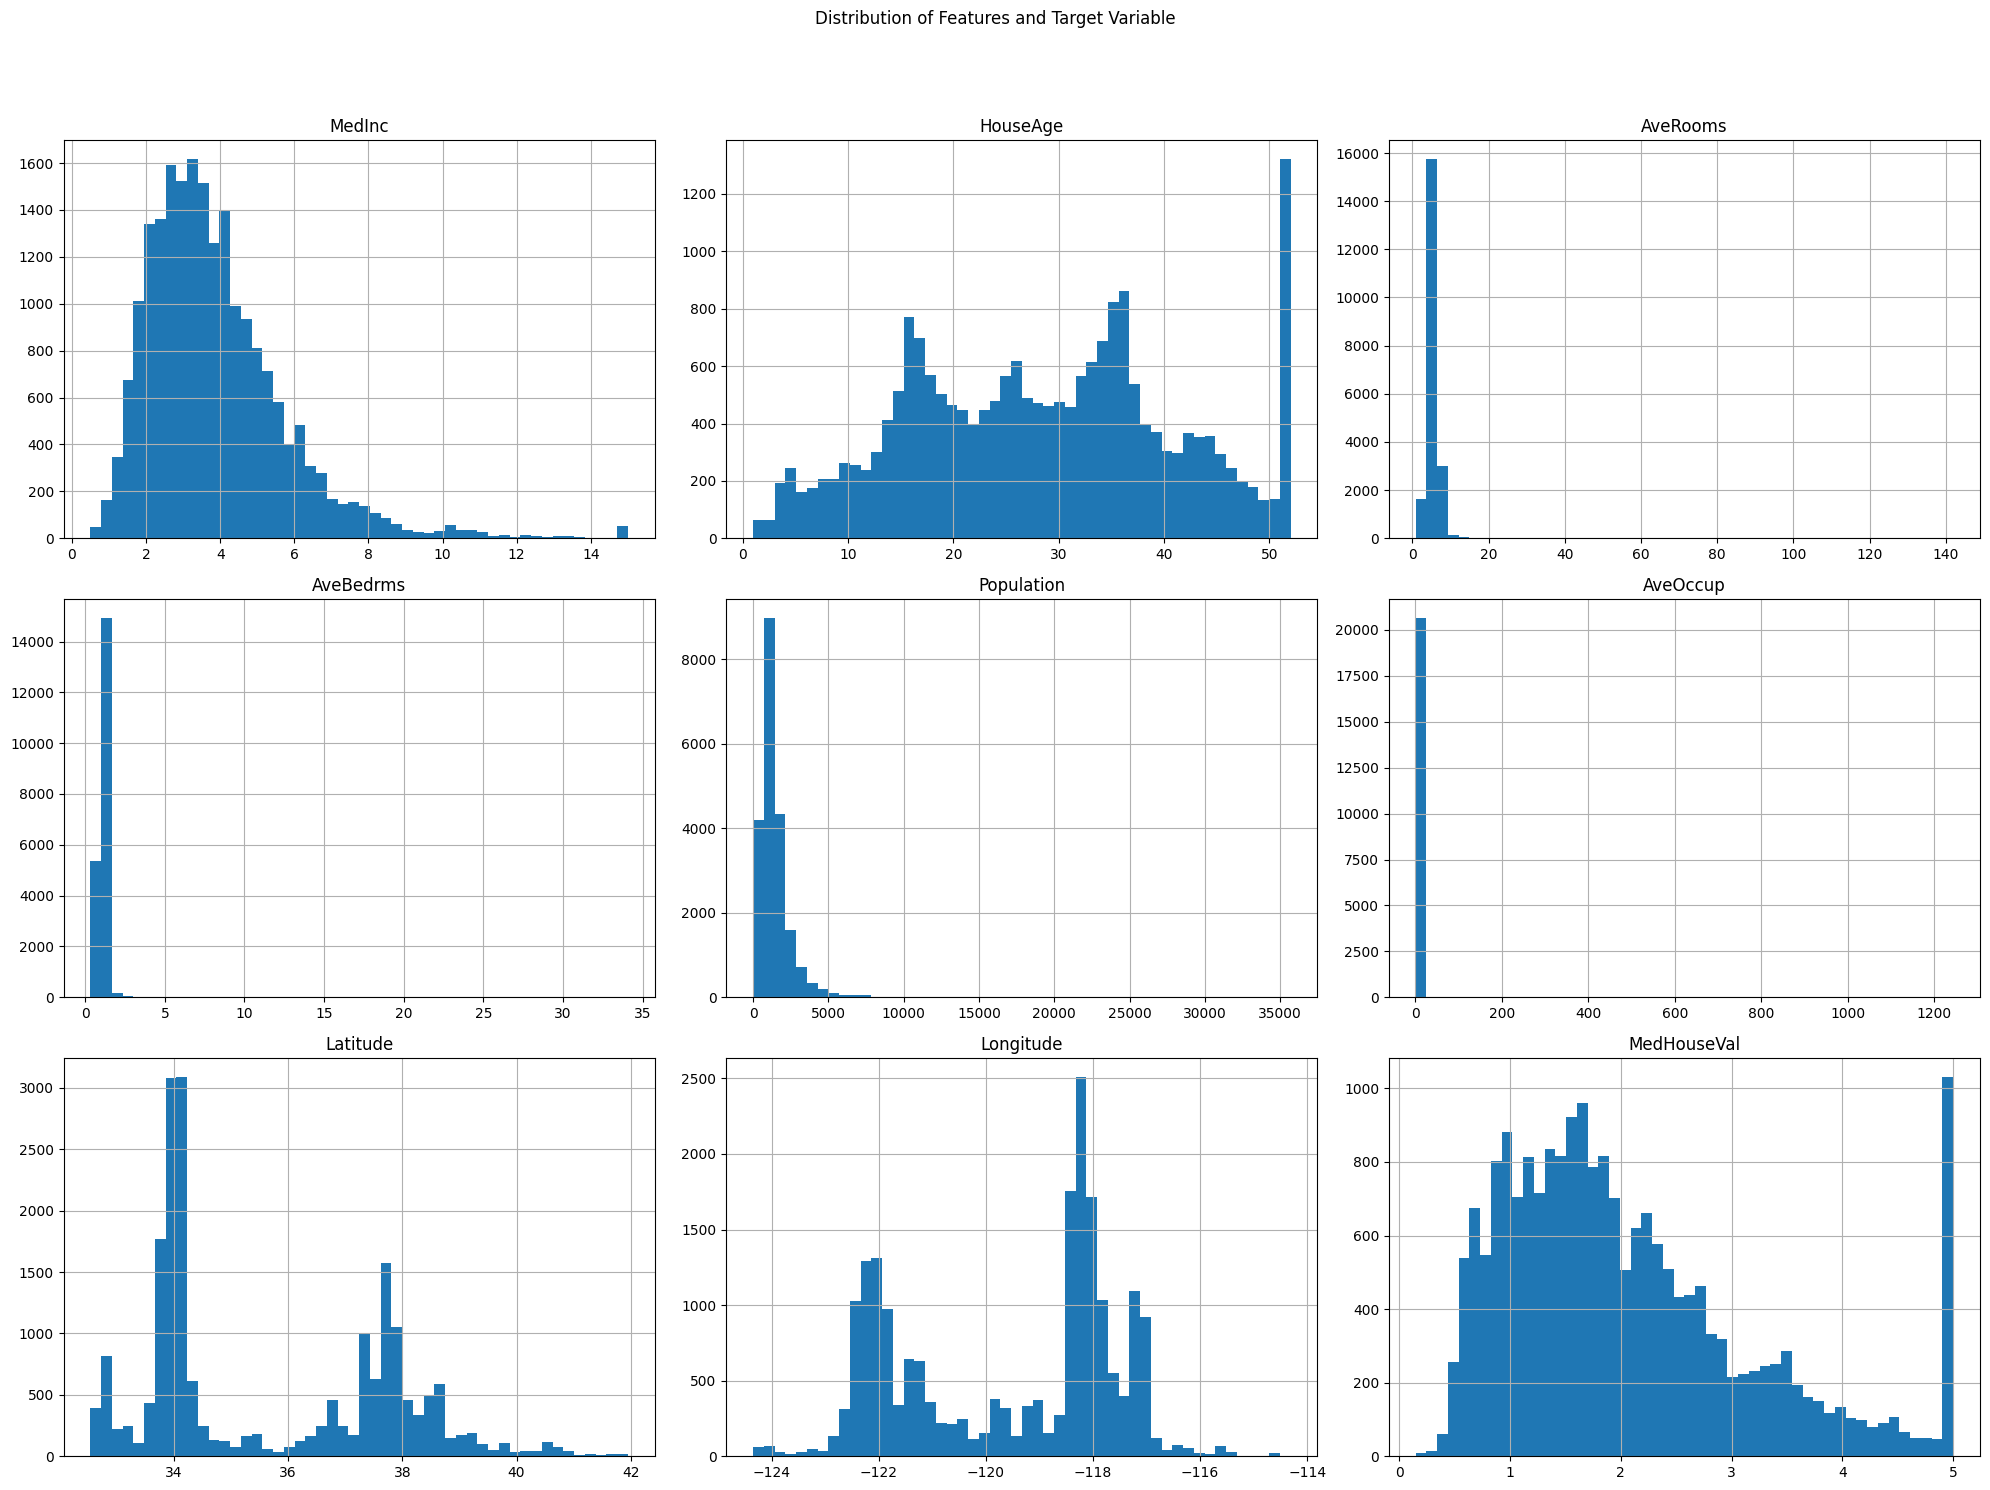

In [7]:
# Plot histograms for all numerical features and the target variable
df.hist(bins=50, figsize=(20, 15))
plt.suptitle('Distribution of Features and Target Variable', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Correlation Matrix

Understanding the correlation between features and the target variable is crucial. A heatmap can visually represent these correlations.

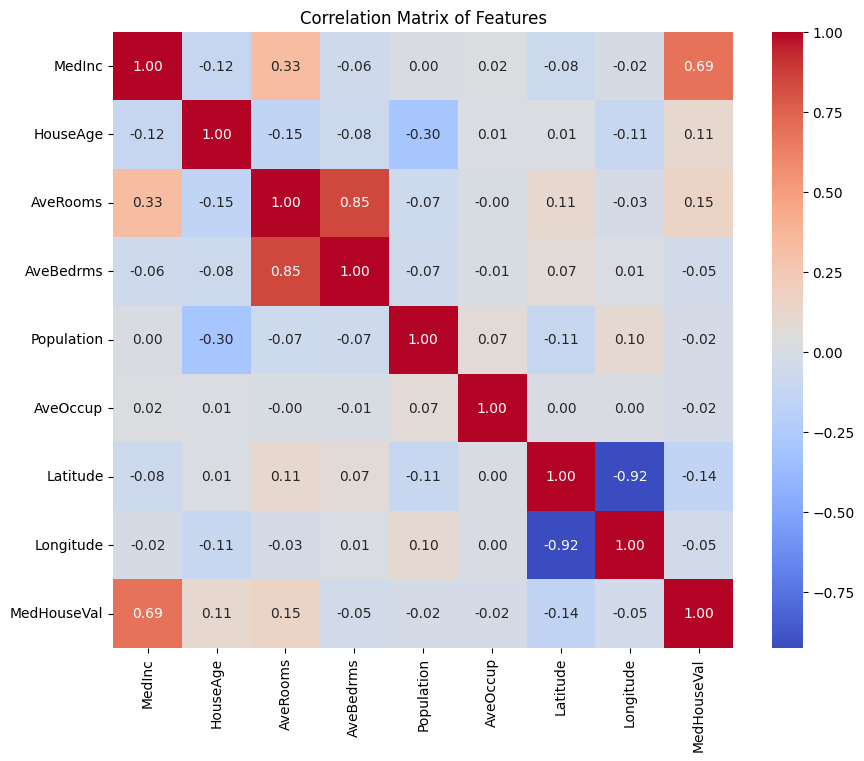

In [8]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

### 3. Data Preprocessing

 Prepare the data for machine learning model.

In [9]:
# Define features (X) and target (y)
X = df.drop('MedHouseVal', axis=1) # All columns except target variable
y = df['MedHouseVal'] # MedHouseVal is the target variable

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (20640, 8)
Target (y) shape: (20640,)


In [10]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


### Feature Scaling

Apply `StandardScaler` to scale our features.Many machine learning algorithms perform better when numerical input variables are scaled to a standard range.

In [11]:
# Scale the features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print("First 5 rows of scaled X_train:")
print(X_train_scaled[:5])

Features scaled successfully.
First 5 rows of scaled X_train:
[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 -0.25753771 -0.44981806 -0.03227969
  -0.46014647 -0.44760309]
 [-1.01786438  0.58654547 -0.60001532 -0.14515634 -0.00743434  0.07750687
  -1.38217186  1.23269811]
 [-0.17148831  1.14200767  0.3490073   0.08662432 -0.48587717 -0.06883176
   0.5320839  -0.10855122]]


### 4. Model Training

Now, let's train a regression model using our scaled training data.

In [22]:
# Import the Linear Regression model
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 5. Model Evaluation

After training the model, it's essential to evaluate its performance to understand how well it generalizes to new, unseen data.

In [23]:
# Make predictions on the training and testing sets
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("Predictions made successfully.")

Predictions made successfully.


In [24]:
# Evaluate model performance on the training set
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print("--- Training Set Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_train:.4f}")
print(f"Mean Squared Error (MSE): {mse_train:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train:.4f}")
print(f"R-squared (R2): {r2_train:.4f}")

--- Training Set Evaluation ---
Mean Absolute Error (MAE): 0.5286
Mean Squared Error (MSE): 0.5179
Root Mean Squared Error (RMSE): 0.7197
R-squared (R2): 0.6126


In [25]:
# Evaluate model performance on the testing set
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("\n--- Testing Set Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"Mean Squared Error (MSE): {mse_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"R-squared (R2): {r2_test:.4f}")


--- Testing Set Evaluation ---
Mean Absolute Error (MAE): 0.5332
Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
R-squared (R2): 0.5758


### Visualizing Predictions

Visualize the model's predictions against the actual values.

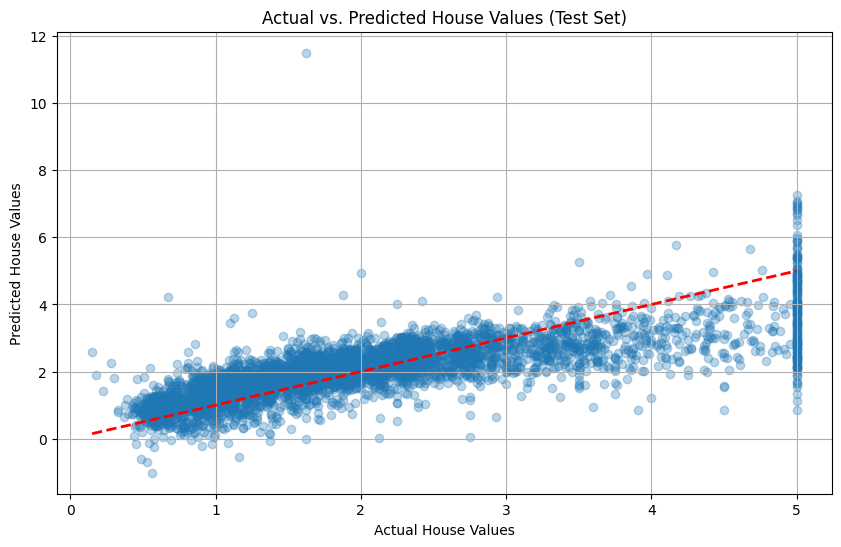

In [26]:
# Plotting actual vs. predicted values for the test set
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.xlabel('Actual House Values')
plt.ylabel('Predicted House Values')
plt.title('Actual vs. Predicted House Values (Test Set)')
plt.grid(True)
plt.show()

### Conclusion and Next Steps

I've completed a basic regression project, from data loading and exploration to model training and evaluation. The Linear Regression model provides a baseline for house price prediction.

**Possible Next Steps:**

*   **Feature Engineering**: Create new features from existing ones (e.g., total rooms, rooms per household).
*   **More Advanced Models**: Experiment with other regression algorithms like RandomForestRegressor, GradientBoostingRegressor, or XGBoost.
*   **Hyperparameter Tuning**: Optimize the chosen model's parameters for better performance.
*   **Cross-Validation**: Use cross-validation to get a more robust estimate of model performance.
*   **Error Analysis**: Analyze where the model makes mistakes to identify areas for improvement.